# 1. Frame the problem
Using the customer description, Define the problem your trying to solve in your own words (remember this is not technial but must be specific so the customer understands the project

Customer needs a model that can analyze hand written cursive, and predict what character is written.

# 2. Get the Data 
Define how you recieved the data (provided, gathered..)

Data has been given to us by the boss/customer through a google drive link.

# 3. Explore the Data
Gain insights into the data you have from step 2, making sure to identify any bias

Uploaded the data to jupyter as a zip file, then unzipped using unzip, then added folder to .gitignore file to prevent LFS error in github.

Starting scan of 'Cursive'...
Error reading Cursive/S19/L.jpg: cannot identify image file '/home/jupyter-259351/Project_5/Cursive/S19/L.jpg'
Error reading Cursive/S19/D.jpg: cannot identify image file '/home/jupyter-259351/Project_5/Cursive/S19/D.jpg'
Error reading Cursive/S21/L.jpg: cannot identify image file '/home/jupyter-259351/Project_5/Cursive/S21/L.jpg'
Error reading Cursive/S21/D.jpg: cannot identify image file '/home/jupyter-259351/Project_5/Cursive/S21/D.jpg'

Scan complete. Found 372 total images.

--- Data Overview ---
  class_label  width  height  mode extension           filepath
0         S32    530     418  RGBA      .png  Cursive/S32/a.png
1         S32    404     298  RGBA      .png  Cursive/S32/s.png
2         S32    426     308  RGBA      .png  Cursive/S32/h.png
3         S32    472     380  RGBA      .png  Cursive/S32/e.png
4         S32    432     302  RGBA      .png  Cursive/S32/t.png


## 1. Class Distribution (Image Count per Class)
class_label
S1      0
S10   

/tmp/ipykernel_2418666/1639718117.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


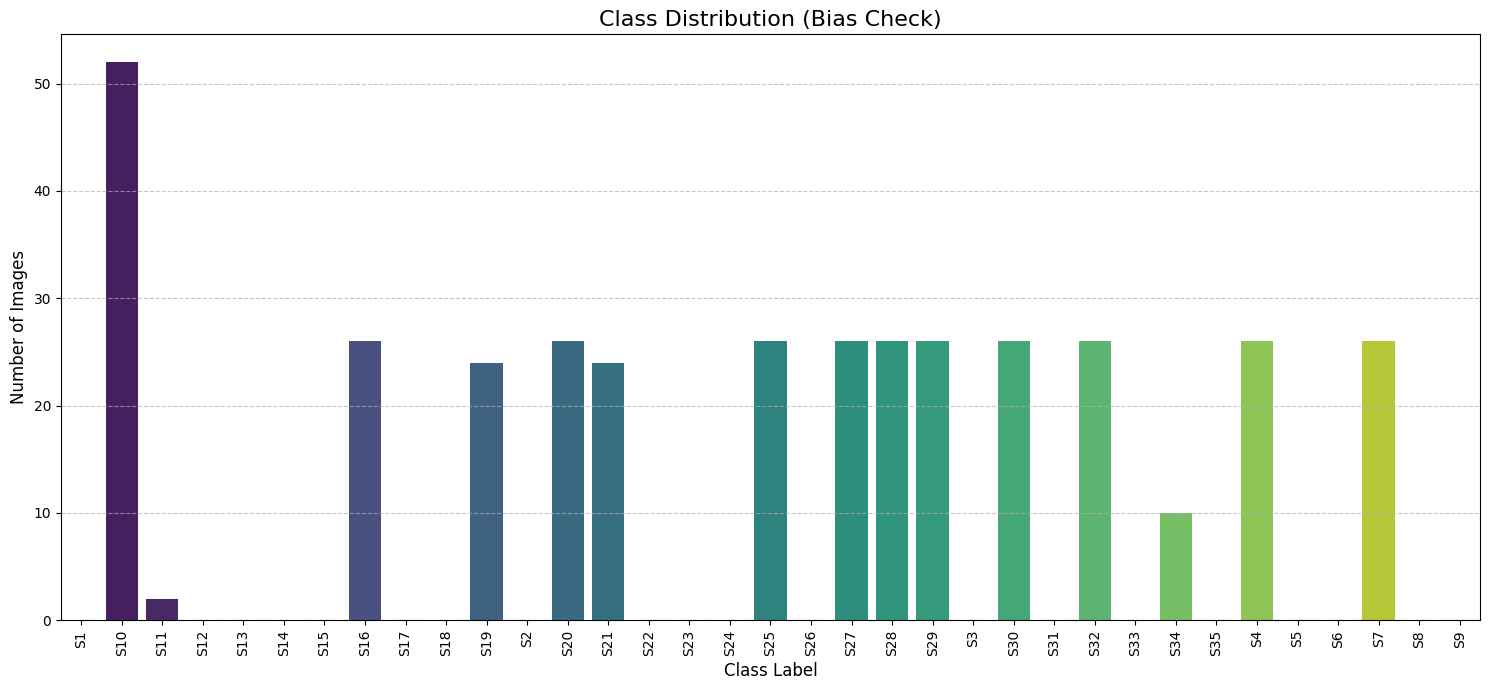

 - Min images in a class: 0
 - Max images in a class: 52
 - Classes with 0 images (empty): ['S1', 'S12', 'S13', 'S14', 'S15', 'S17', 'S18', 'S2', 'S22', 'S23', 'S24', 'S26', 'S3', 'S31', 'S33', 'S35', 'S5', 'S6', 'S8', 'S9']


## 2. Image Dimensions (Width x Height)
Found 232 unique image dimensions.
Top 5 most common dimensions:
     width  height  count
218   3024    4032     28
57     382     478     26
230   3264    2448     10
188   1424    1058      2
143    915    1220      2


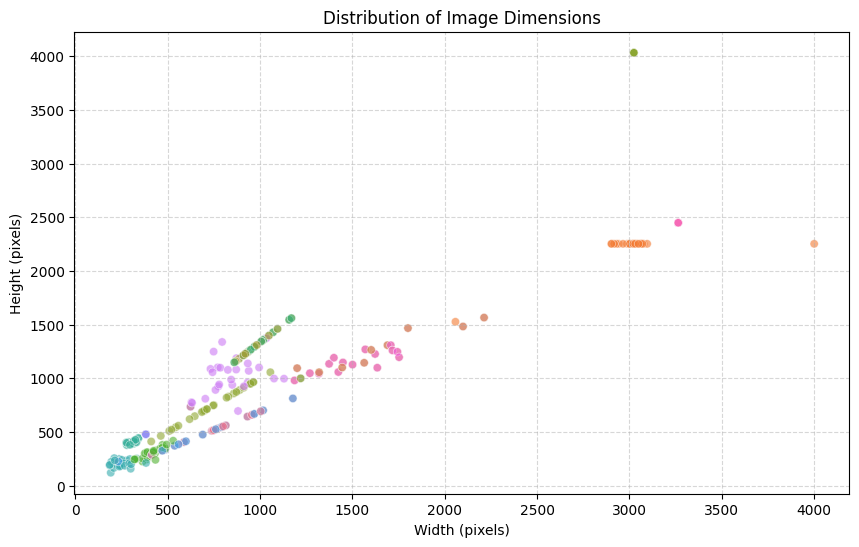



## 3. Image Color Modes
mode
RGB     320
RGBA     52
Name: count, dtype: int64


In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
import numpy as np

main_data_folder = 'Cursive' 
ALL_CLASSES = {f"S{i}" for i in range(1, 36)}
VALID_EXTENSIONS = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff', '.HEIC'}

image_data = []

print(f"Starting scan of '{main_data_folder}'...")

for root, dirs, files in os.walk(main_data_folder, topdown=True):
    
    if root == main_data_folder:
        found_folders = set(dirs)
        missing = ALL_CLASSES - found_folders
        if missing:
            print(f"Warning: Missing class folders: {sorted(list(missing))}")
        continue 

    try:
        rel_path = os.path.relpath(root, main_data_folder)
        class_label = rel_path.split(os.path.sep)[0]
    except ValueError:
        continue 

    if class_label not in ALL_CLASSES:
        continue

    for file in files:
        ext = os.path.splitext(file)[1].lower()
        if ext in VALID_EXTENSIONS:
            filepath = os.path.join(root, file)
            
            try:
                with Image.open(filepath) as img:
                    width, height = img.size
                    mode = img.mode
                
                image_data.append({
                    'class_label': class_label,
                    'width': width,
                    'height': height,
                    'mode': mode,
                    'extension': ext,
                    'filepath': filepath
                })
            except Exception as e:
                print(f"Error reading {filepath}: {e}")

print(f"\nScan complete. Found {len(image_data)} total images.")


if not image_data:
    print("No images found. Please check 'main_data_folder' path.")
else:
    df = pd.DataFrame(image_data)

    print("\n--- Data Overview ---")
    print(df.head())


    print("\n\n## 1. Class Distribution (Image Count per Class)")
    
    class_counts = df['class_label'].value_counts()
    
    for cls in ALL_CLASSES:
        if cls not in class_counts:
            class_counts[cls] = 0
            
    class_counts = class_counts.sort_index()

    print(class_counts)
    
    plt.figure(figsize=(15, 7))
    sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
    plt.title('Class Distribution (Bias Check)', fontsize=16)
    plt.xlabel('Class Label', fontsize=12)
    plt.ylabel('Number of Images', fontsize=12)
    plt.xticks(rotation=90)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

 
    print(f" - Min images in a class: {class_counts.min()}")
    print(f" - Max images in a class: {class_counts.max()}")
    print(f" - Classes with 0 images (empty): {list(class_counts[class_counts == 0].index)}")


    print("\n\n## 2. Image Dimensions (Width x Height)")
    
    dim_counts = df.groupby(['width', 'height']).size().reset_index(name='count')
    dim_counts = dim_counts.sort_values(by='count', ascending=False)
    
    print(f"Found {len(dim_counts)} unique image dimensions.")
    print("Top 5 most common dimensions:")
    print(dim_counts.head(5))
    
    if len(dim_counts) > 1:
        
        
        plt.figure(figsize=(10, 6))
        df_sample = df.sample(min(len(df), 1000)) 
        sns.scatterplot(data=df_sample, x='width', y='height', hue='class_label', 
                        alpha=0.6, legend=False)
        plt.title('Distribution of Image Dimensions')
        plt.xlabel('Width (pixels)')
        plt.ylabel('Height (pixels)')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.show()
    else:
        print("\nAll images have the same dimensions. Excellent!")


    print("\n\n## 3. Image Color Modes")
    
    mode_counts = df['mode'].value_counts()
    print(mode_counts)
    


# 4.Prepare the Data


Apply any data transformations and explain what and why


Convert the txt files into csv.

# 5. Model the data
Using selected ML models, experment with your choices and describe your findings. Finish by selecting a Model to continue with


# 6. Fine Tune the Model

With the select model descibe the steps taken to acheve the best rusults possiable 


# 7. Present
In a customer faceing Document provide summery of finding and detail approach taken


# 8. Launch the Model System
Define your production run code, This should be self susficent and require only your model pramaters 
